# UAS Bengkel Koding Data Science
##Nama : Gabriella Jovanka Bustan
##NIM : A11.2023.14861

##Dataset: `sales_marketing_customer_dataset.csv`
##Link Streamlit : https://churn-customer-prediction-gabriellajovanka.streamlit.app/

---
## 1. Setup & Load Data

**Library yang digunakan:**
- `pandas` / `numpy` → manipulasi data
- `matplotlib` / `seaborn` → visualisasi
- `sklearn` → preprocessing, modeling, evaluasi
- `imblearn` → SMOTE (oversampling kelas minoritas)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib
from sklearn.model_selection import GridSearchCV, train_test_split

# Load Dataset
df = pd.read_csv('sales_marketing_customer_dataset.csv')
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


---
## 2. Eksplorasi Data (EDA)

**Langkah-langkah EDA:**
1. Menampilkan 5 baris pertama, info kolom, dan statistik deskriptif
2. Menghitung persentase *missing value* per kolom
3. Memvisualisasikan distribusi variabel target (`churn`)
4. Membuat *heatmap* korelasi fitur numerik

> 💡 **Insight:** Dataset memiliki **15.000 baris** dan **30 kolom**.  
> Beberapa kolom memiliki *missing value* — yang terbesar adalah `coupon_code` (~40.9%).  
> Variabel target `churn` **tidak seimbang** (sekitar 15.3% churn vs 84.7% tidak churn),  
> sehingga perlu teknik *oversampling* (SMOTE) pada tahap preprocessing.

=== 5 Baris Pertama ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  page

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000



=== Persentase Missing Value ===
customer_id                    0.000000
gender                         4.920000
age                            8.000000
country                        0.000000
city                           0.000000
signup_date                    0.000000
last_purchase_date             0.000000
acquisition_channel            0.000000
device_type                    0.000000
subscription_type              0.000000
is_premium_user                0.000000
total_visits                   0.000000
avg_session_time               0.000000
pages_per_session              0.000000
email_open_rate                0.000000
email_click_rate               0.000000
total_spent                    7.000000
avg_order_value                0.000000
discount_used                  0.000000
coupon_code                   40.886667
support_tickets                0.000000
refund_requested               0.000000
delivery_delay_days            0.000000
payment_method                 0.000000
satisf

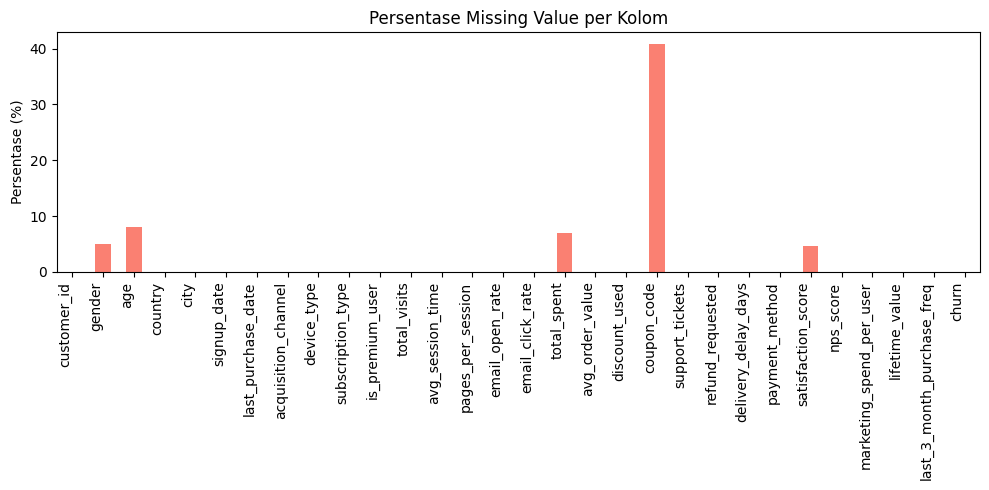

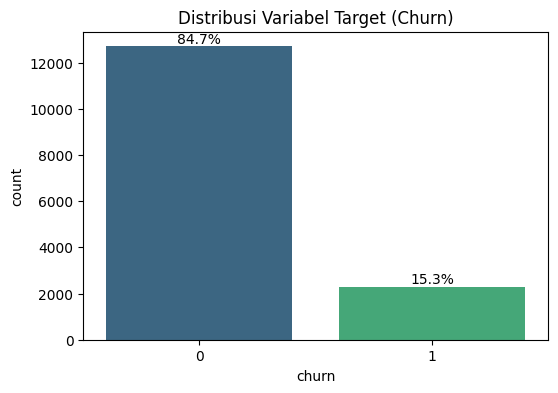

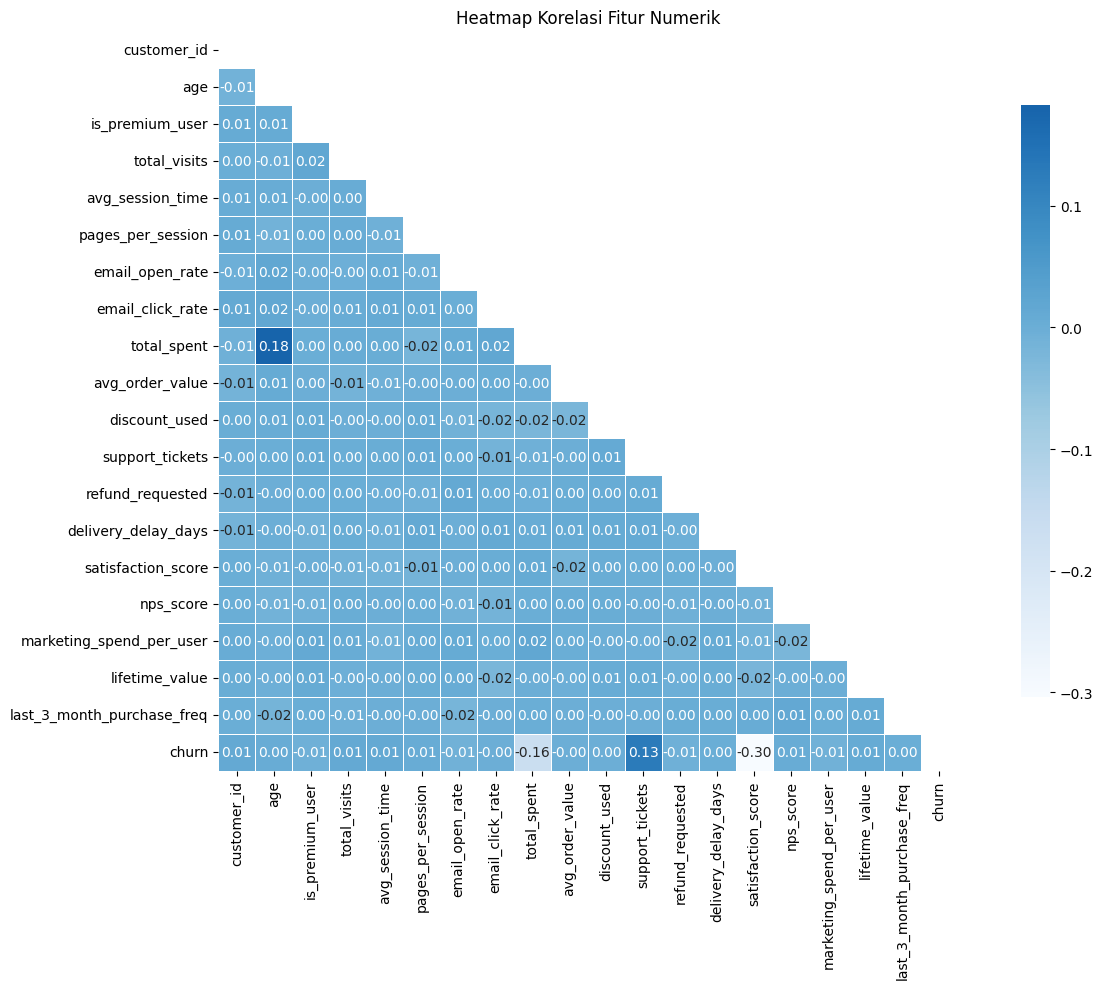


=== Korelasi Fitur terhadap Churn ===
churn                         1.000000
support_tickets               0.127910
total_visits                  0.013212
customer_id                   0.012208
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588
Name: churn, dtype: float64


In [2]:
# 2.1 Menampilkan 5 baris pertama, info, dan statistik deskriptif
print("=== 5 Baris Pertama ===")
display(df.head())

print("\n=== Informasi Dataset ===")
df.info()

print("\n=== Statistik Deskriptif ===")
display(df.describe())

# 2.2 Persentase missing value dan visualisasi diagram batang
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\n=== Persentase Missing Value ===")
print(missing_percent)

plt.figure(figsize=(10, 5))
missing_percent.plot(kind='bar', color='salmon')
plt.title('Persentase Missing Value per Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# 2.3 Visualisasi distribusi variabel target (Churn)
# Nilai 0 = Tidak Churn, 1 = Churn
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribusi Variabel Target (Churn)')

# Menambahkan label persentase di atas batang
total = float(len(df))
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

# 2.4 Heatmap korelasi fitur numerik
# Korelasi negatif kuat terhadap churn → fitur yang meningkat ketika churn turun
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,           # sembunyikan segitiga atas
    annot=True,           # tampilkan angka korelasi
    fmt='.2f',             # format 2 angka di belakang koma (atau pakai '.2e' kalau mau notasi seperti gambar)
    cmap='Blues',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

# Identifikasi hubungan (Opsional: menampilkan korelasi tertinggi terhadap Churn)
print("\n=== Korelasi Fitur terhadap Churn ===")
print(corr['churn'].sort_values(ascending=False))

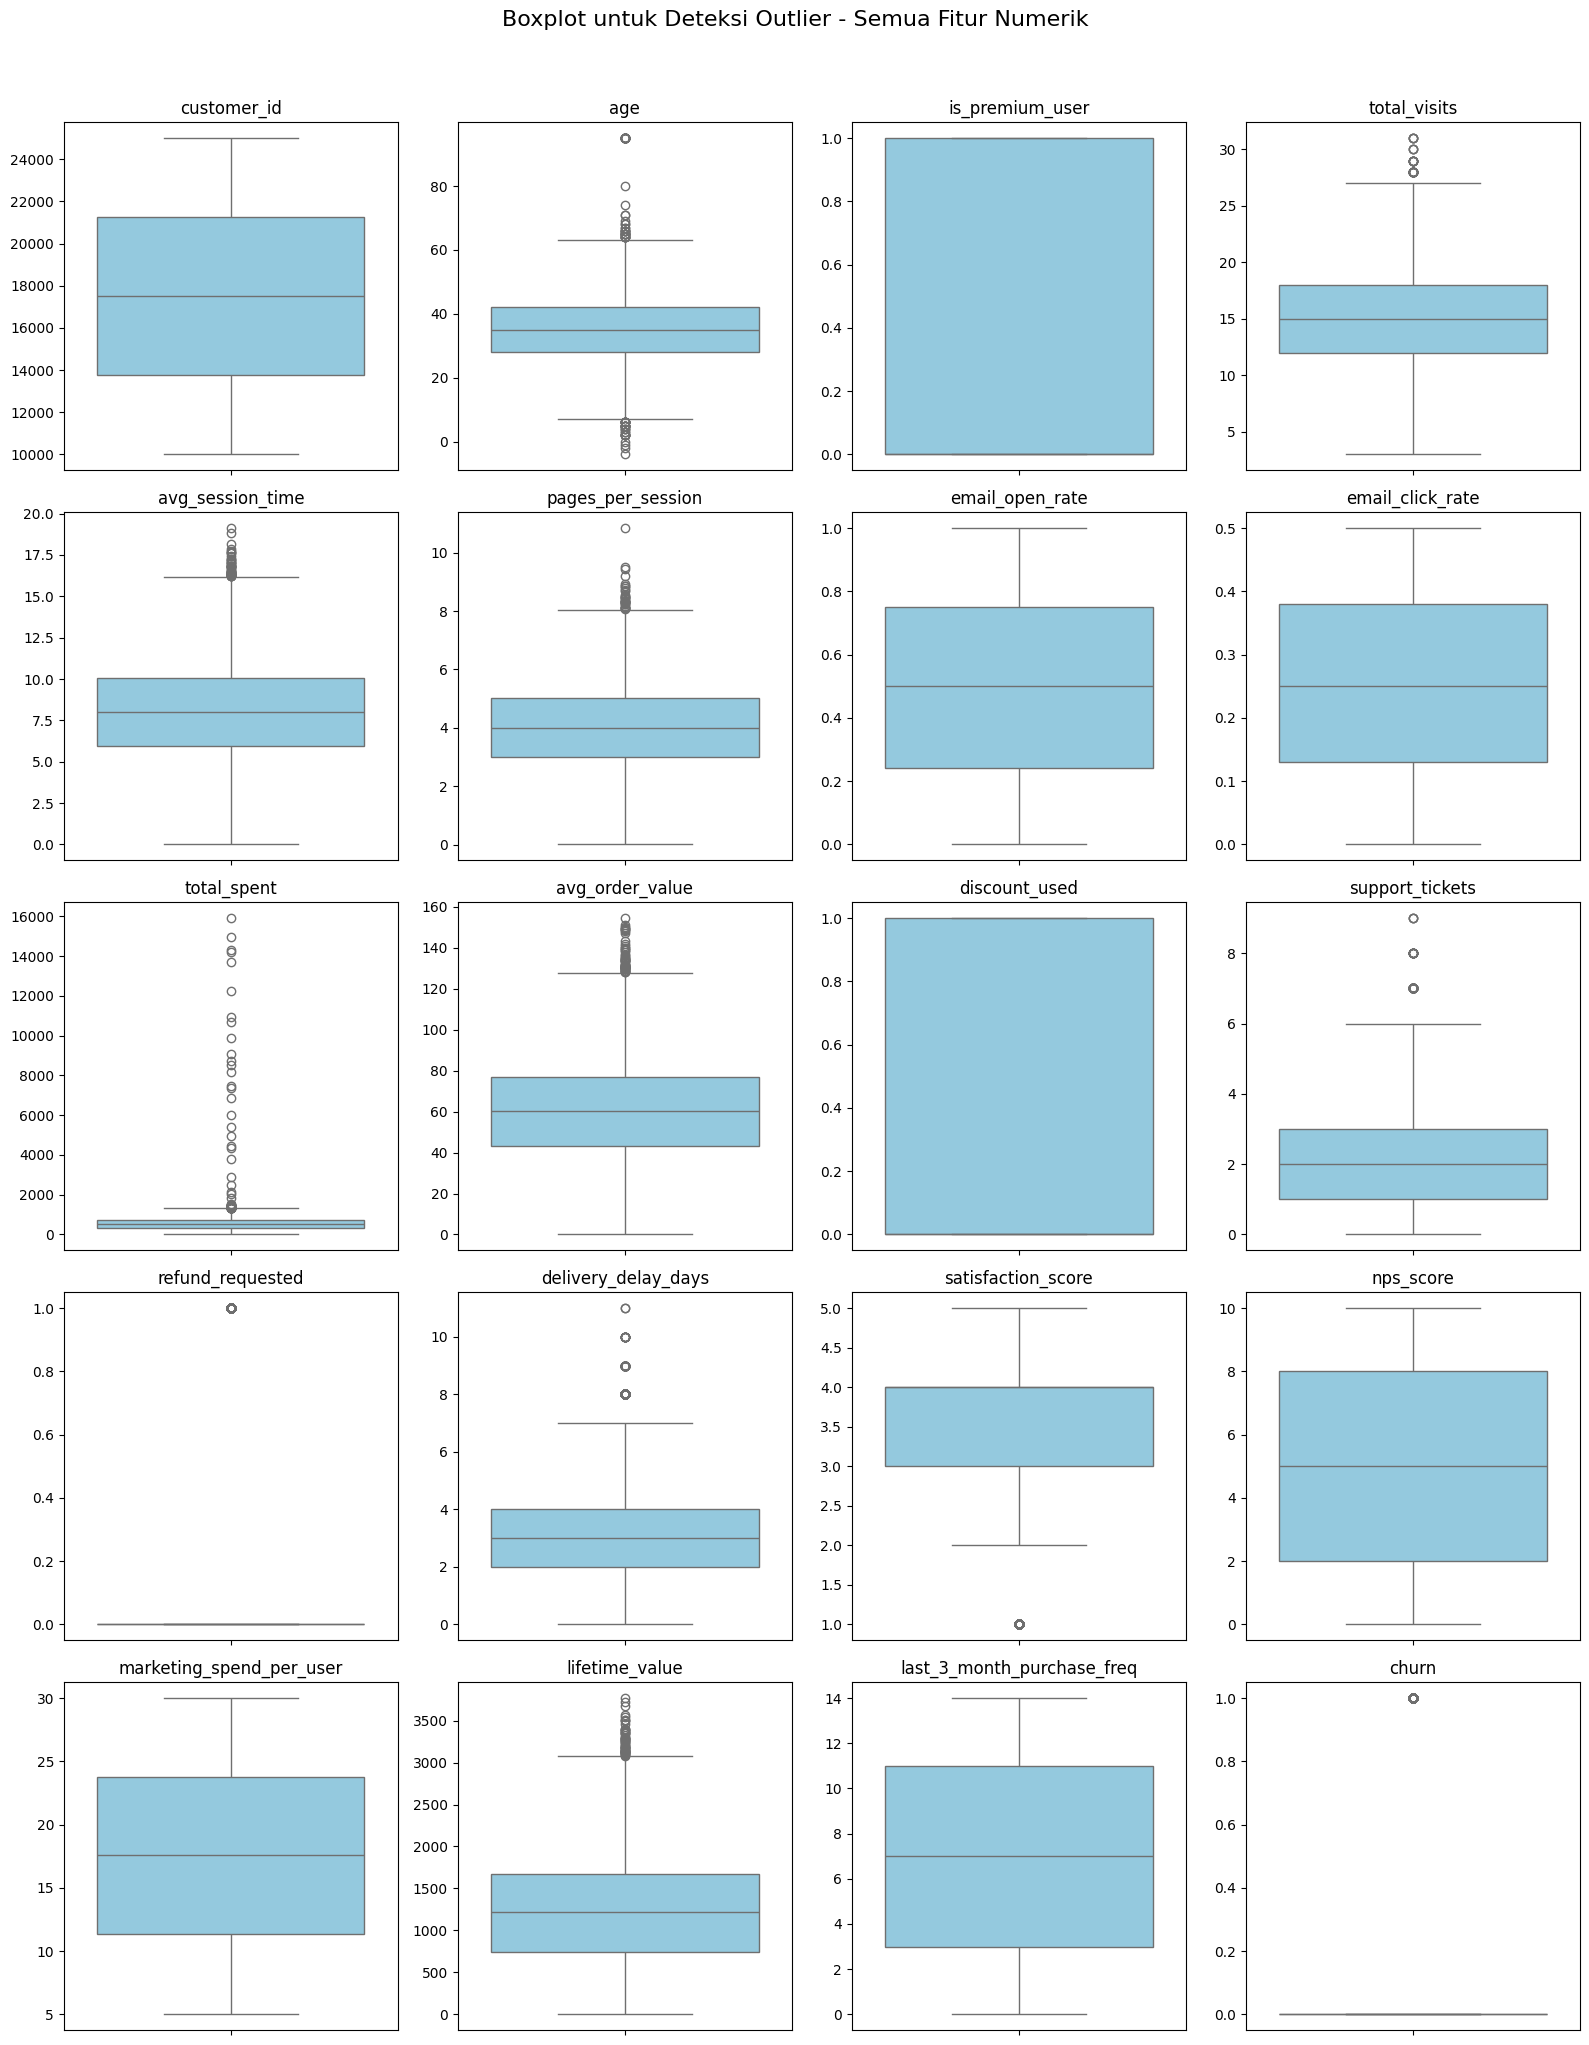

In [3]:
# Pilih semua kolom numerik dari df asli
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Hitung jumlah baris & kolom subplot secara otomatis
n_cols = 4  # jumlah kolom grid, bisa disesuaikan
n_rows = -(-len(numeric_cols) // n_cols)  # pembulatan ke atas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
axes = axes.flatten()  # supaya bisa di-looping dengan index biasa

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hapus subplot kosong kalau jumlah fitur tidak pas dengan grid
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplot untuk Deteksi Outlier - Semua Fitur Numerik', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Direct Modeling (Baseline Tanpa Preprocessing Mendalam)

**Strategi preprocessing instan:**
- Hanya menggunakan kolom **numerik** (kolom non-numerik dibuang sementara)
- Baris yang mengandung *missing value* **dihapus** (bukan diisi/imputasi)

**Model yang diuji:**
| # | Model | Jenis |
|---|-------|-------|
| 1 | Logistic Regression | Konvensional / Linear |
| 2 | Random Forest | Ensemble Bagging |
| 3 | Voting Classifier (LR + SVM + KNN) | Ensemble Voting |

> ⚠️ **Catatan:** Hasil di sini diperkirakan kurang optimal karena kelas `churn` tidak
> seimbang dan fitur kategorik belum di-encode.

=== Hasil Evaluasi Direct Modeling (Update) ===

--- Logistic Regression ---
Accuracy  : 0.8371
Precision : 0.5660
Recall    : 0.1453
F1-Score  : 0.2312

--- Random Forest ---
Accuracy  : 0.8400
Precision : 0.5439
Recall    : 0.3148
F1-Score  : 0.3988

--- Voting Classifier ---
Accuracy  : 0.8335
Precision : 0.5758
Recall    : 0.0460
F1-Score  : 0.0852



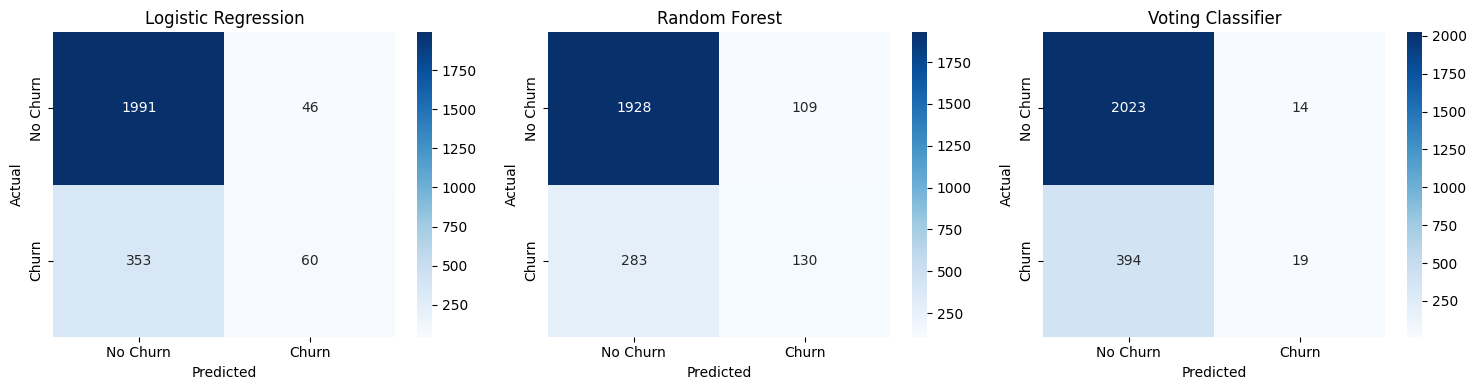

In [4]:
# 3.1 Preprocessing instan untuk direct modeling
# Membuang baris yang mengandung missing value (tanpa diisi 0)
df_direct = numeric_df.dropna()

X_direct = df_direct.drop('churn', axis=1)
y_direct = df_direct['churn']

# 3.2 Train-test split (80:20, random_state=42)
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(X_direct, y_direct, test_size=0.2, random_state=42)

# 3.3 Mendefinisikan Model
models = {
    # Model Konvensional (Logistic Regression: model linear, mudah diinterpretasi)
    'Logistic Regression': LogisticRegression(max_iter=1000),

    # Model Ensemble Bagging (Random Forest: ensemble pohon keputusan (Bagging) → tahan terhadap noise)
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),

    # Voting Classifier (gabungan LR + SVM + KNN dengan voting mayoritas (hard))
    'Voting Classifier': VotingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC()),
        ('knn', KNeighborsClassifier())
    ], voting='hard')
}

# 3.4 & 3.5 Melatih dan Mengevaluasi Model
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))
print("=== Hasil Evaluasi Direct Modeling (Update) ===\n")

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)

    print(f"--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_test_dir, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_dir, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test_dir, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test_dir, y_pred):.4f}\n")

    cm = confusion_matrix(y_test_dir, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
## 4. Modeling dengan Preprocessing Lengkap

### Tahapan Preprocessing:

| Tahap | Teknik | Alasan |
|-------|--------|--------|
| 4a | **Deduplication** | Baris duplikat menyebabkan model *overfit* ke data redundan |
| 4b | **Feature Engineering** (`tenure_days`) | Kolom tanggal tidak dapat langsung dipakai model; durasi pelanggan lebih informatif |
| 4c | **Imputasi Missing Value** | Kolom numerik → median (robust terhadap outlier); kategorik → modus |
| 4d | **Outlier Capping (IQR)** | Nilai ekstrem di-*cap* di batas IQR agar tidak mendistorsi model |
| 4e | **Hybrid Encoding** | Label Encoding untuk kolom ordinal/high-cardinality; OHE untuk nominal low-cardinality |
| 4f | **SMOTE** | Dataset churn tidak seimbang (~15% vs 85%); SMOTE membuat data sintetis kelas minoritas |
| 4g | **StandardScaler** | SVM dan KNN sensitif terhadap skala fitur; normalisasi membantu konvergensi model |

Jumlah duplikasi sebelum: 0
Fitur baru 'tenure_days' berhasil ditambahkan!
Jumlah fitur/kolom setelah Hybrid Encoding: 44

=== Hasil Evaluasi Modeling dengan Preprocessing + SMOTE + Feature Engineering ===
--- Logistic Regression ---
Accuracy  : 0.8530
Precision : 0.5087
Recall    : 0.1982
F1-Score  : 0.2853

--- Random Forest ---
Accuracy  : 0.8523
Precision : 0.5011
Recall    : 0.5270
F1-Score  : 0.5137

--- Voting Classifier ---
Accuracy  : 0.8500
Precision : 0.4483
Recall    : 0.0586
F1-Score  : 0.1036



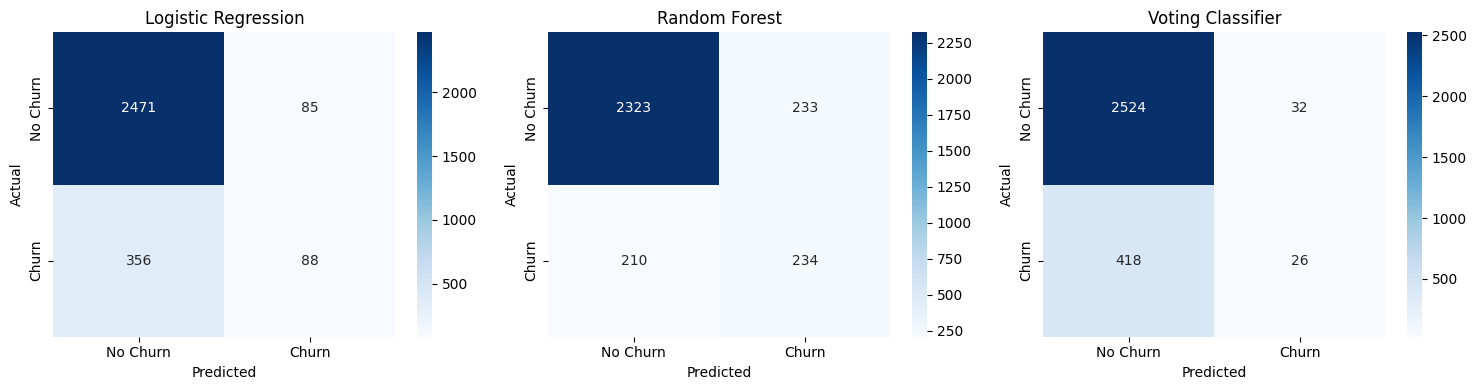

In [5]:
df_prep = df.copy()

# 4a Handling Duplikasi
print("Jumlah duplikasi sebelum:", df_prep.duplicated().sum())
df_prep = df_prep.drop_duplicates()

# =======================================================
# 4b FEATURE ENGINEERING (Rekayasa Fitur Baru)
# =======================================================

# Kolom signup_date dan last_purchase_date adalah tipe string → ubah ke datetime
# lalu hitung selisih hari sebagai fitur 'tenure_days'
# Alasan: durasi pelanggan (berapa lama menggunakan layanan) berpotensi
# menjadi prediktor kuat untuk churn.

# Ubah kolom menjadi format datetime
df_prep['signup_date'] = pd.to_datetime(df_prep['signup_date'], errors='coerce')
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'], errors='coerce')

# Buat fitur baru: tenure_days (Lama pelanggan menggunakan layanan dalam hitungan hari)
df_prep['tenure_days'] = (df_prep['last_purchase_date'] - df_prep['signup_date']).dt.days

# Jika ada hasil perhitungan hari yang kosong (karena tanggalnya hilang), isi dengan median
df_prep['tenure_days'] = df_prep['tenure_days'].fillna(df_prep['tenure_days'].median())

# Hapus fitur tanggal dan ID (sudah tidak diperlukan setelah feature engineering)
df_prep = df_prep.drop(['customer_id', 'signup_date', 'last_purchase_date'], axis=1, errors='ignore')
print("Fitur baru 'tenure_days' berhasil ditambahkan!")
# =======================================================

# 4c Handling Missing Value
# Numerik → median (tidak sensitif terhadap outlier)
# Kategorik → modus (nilai paling sering muncul)
for col in df_prep.columns:
    if df_prep[col].dtype == 'object':
        df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])
    else:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# 4d Handling Outlier Capping (IQR)
# Nilai di luar [Q1 - 1.5*IQR, Q3 + 1.5*IQR] di-cap ke batas tersebut
# Mengurangi pengaruh nilai ekstrem tanpa membuang data
numeric_cols = df_prep.select_dtypes(include=[np.number]).columns.drop('churn', errors='ignore')
for col in numeric_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping nilai pencilan (outlier)
    df_prep[col] = np.where(df_prep[col] > upper_bound, upper_bound,
                   np.where(df_prep[col] < lower_bound, lower_bound, df_prep[col]))

# =======================================================
# 4e HYBRID ENCODING (Label Encoding + OHE)
# =======================================================
# Label Encoding untuk data Ordinal dan Nominal dengan banyak kategori
# (kardinality tinggi → OHE akan menghasilkan terlalu banyak kolom)
le_cols = ['city', 'coupon_code', 'subscription_type']
for col in le_cols:
    if col in df_prep.columns:
        df_prep[col] = LabelEncoder().fit_transform(df_prep[col].astype(str))

# One-Hot Encoding (OHE) untuk data Nominal dengan sedikit kategori
ohe_cols = ['gender', 'country', 'acquisition_channel', 'device_type', 'payment_method']
ohe_cols_existing = [col for col in ohe_cols if col in df_prep.columns]

# Menerapkan OHE (drop_first=False agar semua kategori utuh termasuk semua jenis gender dan negara)
# drop_first=False → pertahankan semua kategori agar tidak kehilangan informasi
df_prep = pd.get_dummies(df_prep, columns=ohe_cols_existing, drop_first=False)
print(f"Jumlah fitur/kolom setelah Hybrid Encoding: {df_prep.shape[1]}")
# =======================================================

# Menetapkan fitur (X) dan target (y)
X_prep = df_prep.drop('churn', axis=1)
y_prep = df_prep['churn']

# Train-test split
X_train_prep, X_test_prep, y_train_prep, y_test_prep = train_test_split(X_prep, y_prep, test_size=0.2, random_state=42)

# ==========================================
# 4f PENERAPAN SMOTE (Hanya pada Data Training)
# ==========================================

# SMOTE = Synthetic Minority Over-sampling Technique
# Membuat data sintetis untuk kelas minoritas (churn=1) agar distribusi seimbang
# PENTING: SMOTE HANYA diterapkan pada data training untuk menghindari data leakage

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_prep, y_train_prep)

# 4g. Feature Scaling (StandardScaler -> Sangat penting untuk SVM dan KNN)
# Normalisasi: mean=0, std=1 → penting untuk SVM dan KNN
# fit() hanya pada training data untuk mencegah data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_prep)

# Mendefinisikan Model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Voting Classifier': VotingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC()),
        ('knn', KNeighborsClassifier())
    ], voting='hard')
}

# Evaluasi Model (Looping untuk setiap model yang didefinisikan)
print("\n=== Hasil Evaluasi Modeling dengan Preprocessing + SMOTE + Feature Engineering ===")

fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))

for ax, (name, model) in zip(axes, models.items()):
    # Melatih model menggunakan data training yang sudah di-SMOTE dan di-Scaling
    model.fit(X_train_scaled, y_train_smote)

    # Memprediksi data test (sudah di-scale)
    y_pred = model.predict(X_test_scaled)

    print(f"--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_test_prep, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_prep, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test_prep, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test_prep, y_pred):.4f}\n")

    # Confusion Matrix
    cm = confusion_matrix(y_test_prep, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
## 5. Hyperparameter Tuning & Feature Selection

### 5.1 Feature Importance
Sebelum tuning, dilakukan analisis feature importance menggunakan Random Forest
sebagai *explainer*. Ini membantu memahami fitur mana yang paling berpengaruh
terhadap prediksi churn.

> 📌 **Alasan pakai RF untuk feature importance:**  
> Random Forest secara natural menghasilkan skor importance berdasarkan seberapa sering
> suatu fitur digunakan untuk membagi node dan seberapa besar penurunan impurity-nya.

### 5.2 GridSearchCV — 3 Strategi Bersaing

| Strategi | Model | Parameter yang Dituning |
|----------|-------|-------------------------|
| A — Konvensional | Logistic Regression | `C` |
| B — Bagging | Random Forest | `n_estimators`, `max_depth` |
| C — Voting | LR + SVM + KNN | `weights`, `lr__C`, `svm__C` |

> 📌 **Metrik optimisasi: F1-Score**  
> F1-Score digunakan karena dataset imbalanced; akurasi saja tidak cukup.

### 5.3 Penentuan Best Estimator
Model dengan CV F1-Score tertinggi dipilih sebagai **juara strategi** dan kemudian
dilatih ulang (*refit*) pada seluruh data training yang sudah diproses.

--- 5.1 Analisis Feature Importance ---


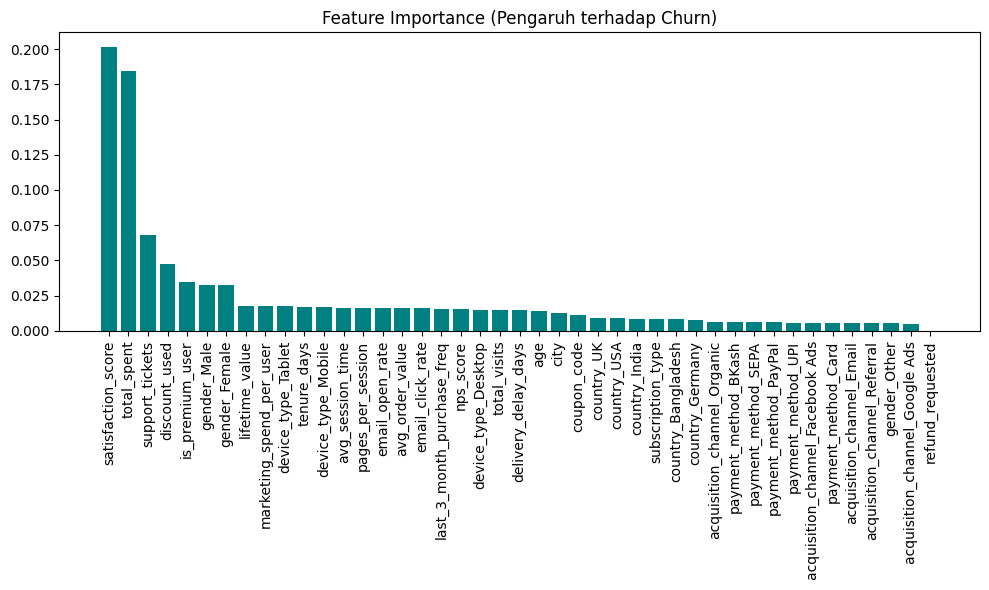


--- 5.2 Hyperparameter Tuning (Kompetisi 3 Strategi) ---
Sedang melakukan tuning pada: Model Konvensional (LR)...
Sedang melakukan tuning pada: Model Bagging (RF)...
Sedang melakukan tuning pada: Model Voting Classifier...

--- JUARA STRATEGI: Bagging (RF) ---
Best Parameters: {'max_depth': 10, 'n_estimators': 100}

--- 5. Melatih kembali Bagging (RF) dengan data latih optimal ---

--- 6. Evaluasi Performa Bagging (RF) ---
Accuracy  : 0.8470
Precision : 0.4878
Recall    : 0.6734
F1-Score  : 0.5658


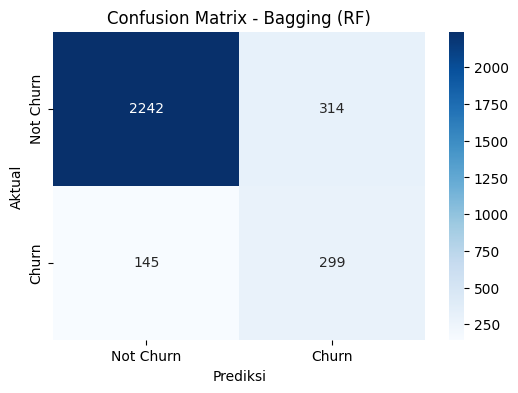


Model juara telah disimpan sebagai 'best_churn_model.pkl'!


In [6]:
# =====================================================================
# 5.1 Analisis Feature Importance (Menggunakan RF sebagai Explainer)
# =====================================================================
print("--- 5.1 Analisis Feature Importance ---")
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_train_scaled, y_train_smote)

importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_prep.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Pengaruh terhadap Churn)")
plt.bar(range(X_train_scaled.shape[1]), importances[indices], color='teal')
plt.xticks(range(X_train_scaled.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# =====================================================================
# 5.2 GridSearchCV untuk 3 Strategi
# =====================================================================
print("\n--- 5.2 Hyperparameter Tuning (Kompetisi 3 Strategi) ---")

# A. Konvensional (Logistic Regression)
# Parameter C: regularization strength (semakin kecil → regularisasi lebih kuat)
model_a = LogisticRegression(max_iter=2000)
params_a = {'C': [0.1, 1, 10]}

# B. Ensemble Bagging (Random Forest)
# n_estimators: jumlah pohon; max_depth: kedalaman maksimum pohon (None = tidak dibatasi)
model_b = RandomForestClassifier(random_state=42)
params_b = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10]}

# C. Voting Classifier (LR + SVM + KNN)
# voting='soft' → gunakan probabilitas untuk voting (lebih informatif dari hard voting)
# weights → bobot kontribusi tiap model dalam voting
model_c = VotingClassifier(estimators=[
    ('lr', LogisticRegression(max_iter=2000)),
    ('svm', SVC(probability=True)),
    ('knn', KNeighborsClassifier())
], voting='soft', weights=[2, 1, 1])
params_c = {
    'weights': [[1, 1, 1], [2, 1, 1], [1, 2, 1]],
    'lr__C': [0.1, 1],
    'svm__C': [0.1, 1],
    # 'knn__n_neighbors': [3, 5]
}

def get_best_model(model, params, name):
    print(f"Sedang melakukan tuning pada: {name}...")
    grid = GridSearchCV(model, params, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train_scaled, y_train_smote)
    return grid.best_estimator_, grid.best_score_, grid.best_params_

best_a, score_a, param_a = get_best_model(model_a, params_a, "Model Konvensional (LR)")
best_b, score_b, param_b = get_best_model(model_b, params_b, "Model Bagging (RF)")
best_c, score_c, param_c = get_best_model(model_c, params_c, "Model Voting Classifier")

# =====================================================================
# 5.3 Penentuan Best Estimator
# =====================================================================
results = [('Konvensional (LR)', score_a, best_a, param_a),
           ('Bagging (RF)', score_b, best_b, param_b),
           ('Voting Classifier', score_c, best_c, param_c)]

best_strategy = max(results, key=lambda item: item[1])
print(f"\n--- JUARA STRATEGI: {best_strategy[0]} ---")
print(f"Best Parameters: {best_strategy[3]}")

# 5.4 Refit Best Estimator pada seluruh data training
# GridSearchCV dengan refit=True (default) sudah otomatis melatih ulang
# best estimator pada seluruh training data setelah CV selesai.
# Baris .fit() di bawah ini bersifat eksplisit/konfirmasi.
best_model_final = best_strategy[2]
print(f"\n--- 5. Melatih kembali {best_strategy[0]} dengan data latih optimal ---")
best_model_final.fit(X_train_scaled, y_train_smote)

# 5.5 Evaluasi Model Terbaik
print(f"\n--- 6. Evaluasi Performa {best_strategy[0]} ---")
y_pred_final = best_model_final.predict(X_test_scaled)

print(f"Accuracy  : {accuracy_score(y_test_prep, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test_prep, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test_prep, y_pred_final):.4f}")
print(f"F1-Score  : {f1_score(y_test_prep, y_pred_final):.4f}")

# Confusion Matrix model terbaik
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_prep, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_strategy[0]}')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# Simpan model sementara
joblib.dump(best_model_final, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nModel juara telah disimpan sebagai 'best_churn_model.pkl'!")

---
## 6. Evaluasi Perbandingan Menyeluruh (3 Model)

> ⚠️ **Catatan Teknis:**  
> Confusion matrix di sini menggunakan `best_b` (RF setelah tuning) yang berbeda
> dengan confusion matrix di bagian 5.5 yang menggunakan `best_model_final` (model juara).  
> Perbedaan hasil muncul karena `best_model_final.fit()` di bagian 5 bisa sedikit
> mengubah internal state model karena `best_model_final` hanyalah alias (bukan salinan)
> dari `best_b`. Solusi: gunakan `sklearn.base.clone()` jika ingin memastikan konsistensi.


--- Tabel Perbandingan Metrik Evaluasi ---
            Model  Accuracy  Precision   Recall  F1-Score
Konvensional (LR)  0.852333   0.502959 0.191441  0.277325
     Bagging (RF)  0.847000   0.487765 0.673423  0.565752
Voting Classifier  0.853333   0.518182 0.128378  0.205776


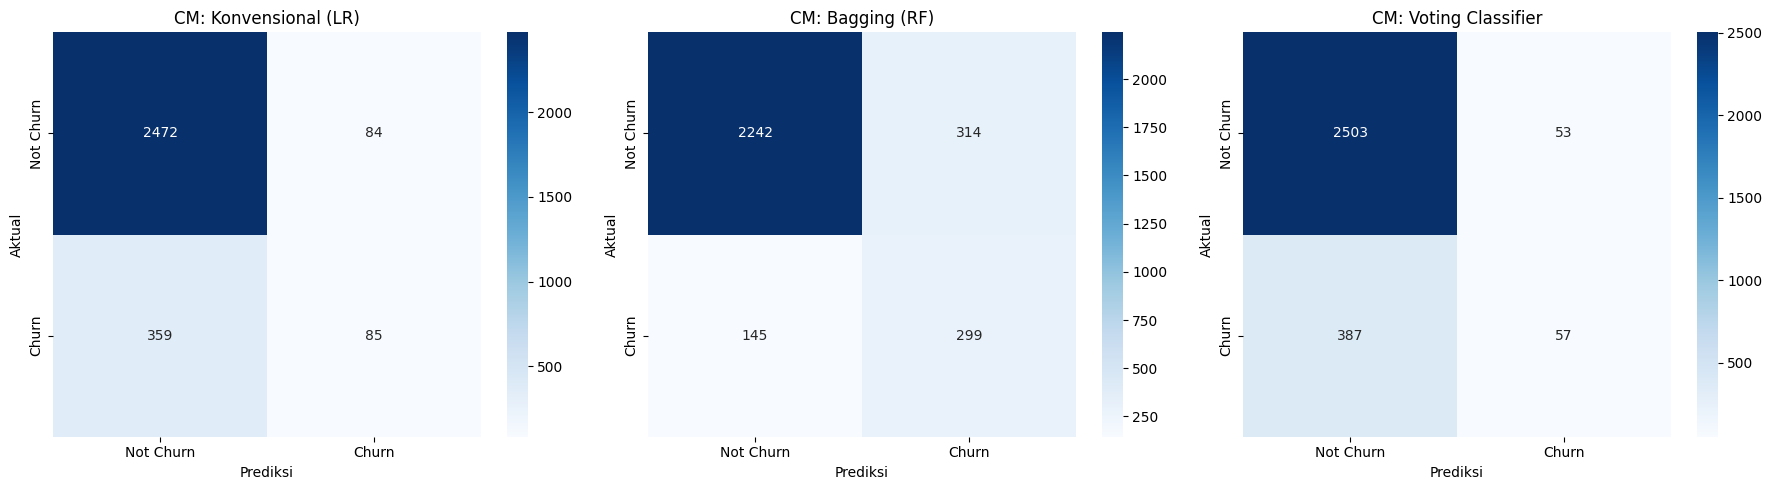

In [7]:
# =====================================================================
# Evaluasi Perbandingan Menyeluruh (3 Model)
# =====================================================================
print("\n--- Tabel Perbandingan Metrik Evaluasi ---")

# Daftar model untuk dievaluasi
models_to_eval = [
    ('Konvensional (LR)', best_a),
    ('Bagging (RF)', best_b),
    ('Voting Classifier', best_c)
]

# List untuk menampung hasil
results_table = []

# Membuat plot untuk Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models_to_eval):
    y_pred = model.predict(X_test_scaled)

    # Menghitung Metrik
    acc = accuracy_score(y_test_prep, y_pred)
    prec = precision_score(y_test_prep, y_pred)
    rec = recall_score(y_test_prep, y_pred)
    f1 = f1_score(y_test_prep, y_pred)

    results_table.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

    # Plotting Confusion Matrix
    cm = confusion_matrix(y_test_prep, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    axes[i].set_title(f'CM: {name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

# Menampilkan Tabel
df_results = pd.DataFrame(results_table)
print(df_results.to_string(index=False))

plt.tight_layout()
plt.show()

### Deployment : Menyimpan Model

In [8]:
import joblib

# Simpan model juara dan scaler
joblib.dump(best_strategy[2], 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model dan Scaler berhasil disimpan!")

Model dan Scaler berhasil disimpan!


In [11]:
from sklearn.feature_selection import SelectFromModel

# Ambil model Random Forest yang sudah di-fit dari dictionary 'models'
rf_model = models['Random Forest']

# threshold='median' artinya ambil fitur dengan importance >= median semua importance
selector = SelectFromModel(rf_model, threshold='median', prefit=True)
X_train_selected = selector.transform(X_train_prep)  # sesuaikan nama X_train kamu

selected_features = X_train_prep.columns[selector.get_support()]
print(f"Jumlah fitur terpilih: {len(selected_features)}")
print(selected_features.tolist())

Jumlah fitur terpilih: 22
['is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'tenure_days', 'gender_Female', 'gender_Male', 'device_type_Desktop', 'device_type_Mobile', 'device_type_Tablet']


In [12]:
import pandas as pd

# Ambil model Random Forest yang sudah di-fit dari dictionary 'models'
rf_model = models['Random Forest']

# Ambil importance dan nama fitur
importances = rf_model.feature_importances_
feature_names = X_train_prep.columns  # nama kolom dari dataframe sebelum di-scale

# Buat dataframe importance, urutkan dari terbesar
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Hitung cumulative importance
feat_imp_df['cumulative_importance'] = feat_imp_df['importance'].cumsum()

# Ambil fitur sampai cumulative importance mencapai threshold (misal 90%)
threshold = 0.90
selected_features = feat_imp_df[feat_imp_df['cumulative_importance'] <= threshold]['feature'].tolist()

print(f"Jumlah fitur terpilih: {len(selected_features)} dari {len(feature_names)} total fitur")
print(selected_features)

Jumlah fitur terpilih: 26 dari 43 total fitur
['satisfaction_score', 'total_spent', 'support_tickets', 'discount_used', 'is_premium_user', 'gender_Male', 'gender_Female', 'lifetime_value', 'marketing_spend_per_user', 'device_type_Tablet', 'tenure_days', 'device_type_Mobile', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'avg_order_value', 'email_click_rate', 'last_3_month_purchase_freq', 'nps_score', 'device_type_Desktop', 'total_visits', 'delivery_delay_days', 'age', 'city', 'coupon_code', 'country_UK']
